# Assignment 1: Introduction to Language Modeling

Build an RNN-based language model from scratch: tokenization, data loading, model definition, training, and evaluation.

Run each cell in sequence.

## Part 0: Setup

In [4]:
# Task 0.1: Environment setup
import torch, nltk, pickle, math
from torch import nn
from collections import Counter
from transformers import BatchEncoding, PretrainedConfig, PreTrainedModel, TrainingArguments
from transformers.modeling_outputs import CausalLMOutput
from torch.utils.data import DataLoader
from datasets import load_dataset
import numpy as np
import sys, time, os

nltk.download('punkt_tab', quiet=True)

TRAIN_FILE = 'train.txt'
VAL_FILE = 'val.txt'
OUTPUT_DIR = 'trained_model'

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
print(f'MPS: {torch.backends.mps.is_available()}')

PyTorch: 2.11.0
CUDA: False
MPS: True


---
## Part 1: Tokenization

### Task 1.1: Word splitting with NLTK

In [5]:
# Task 1.1: Use NLTK word_tokenize for word splitting

def lowercase_tokenizer(text):
    """Tokenize text into lowercase words using NLTK."""
    return [t.lower() for t in nltk.word_tokenize(text)]

# Test it
print(lowercase_tokenizer("Let's test!!"))
print(lowercase_tokenizer("She lives in San Francisco."))

['let', "'s", 'test', '!', '!']
['she', 'lives', 'in', 'san', 'francisco', '.']


### Task 1.2: Building the vocabulary

In [6]:
# Task 1.2: Build vocabulary from training file
#
# - Tokenize all paragraphs, convert to lowercase
# - 4 special symbols: PAD, UNK, BOS, EOS
# - Limit to max_voc_size most frequent tokens
# - Create bidirectional mappings str<->int

def build_tokenizer(train_file, tokenize_fun=lowercase_tokenizer, max_voc_size=None, model_max_length=None,
                    pad_token='<PAD>', unk_token='<UNK>', bos_token='<BOS>', eos_token='<EOS>'):
    """Build a tokenizer from the given file."""

    # Read the training file and count all tokens
    counter = Counter()
    with open(train_file) as f:
        for line in f:
            line = line.strip()
            if line:
                tokens = tokenize_fun(line)
                counter.update(tokens)

    # Build vocabulary: special tokens first, then most frequent
    special_tokens = [pad_token, unk_token, bos_token, eos_token]
    if max_voc_size is not None:
        n_regular = max_voc_size - len(special_tokens)
        most_common = [tok for tok, _ in counter.most_common(n_regular)]
    else:
        most_common = [tok for tok, _ in counter.most_common()]

    vocab = special_tokens + most_common
    str_to_int = {tok: i for i, tok in enumerate(vocab)}

    return A1Tokenizer(
        str_to_int=str_to_int,
        tokenize_fun=tokenize_fun,
        pad_token=pad_token,
        unk_token=unk_token,
        bos_token=bos_token,
        eos_token=eos_token,
        model_max_length=model_max_length,
    )

print('build_tokenizer defined (will be used after A1Tokenizer is defined below).')

build_tokenizer defined (will be used after A1Tokenizer is defined below).


### Task 1.3: Implementing a HuggingFace-like Tokenizer

In [7]:
# Task 1.3: A1Tokenizer class
#
# - __call__: tokenize texts, support padding/truncation, return BatchEncoding
# - __len__: return vocabulary size
# - save/from_file: persistence via pickle

class A1Tokenizer:
    """A minimal implementation of a tokenizer similar to tokenizers in the HuggingFace library."""

    def __init__(self, str_to_int, tokenize_fun, pad_token, unk_token, bos_token, eos_token, model_max_length=None):
        self.str_to_int = str_to_int
        self.int_to_str = {i: s for s, i in str_to_int.items()}
        self.tokenize_fun = tokenize_fun
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token
        self.pad_token_id = str_to_int[pad_token]
        self.unk_token_id = str_to_int[unk_token]
        self.bos_token_id = str_to_int[bos_token]
        self.eos_token_id = str_to_int[eos_token]
        self.model_max_length = model_max_length

    def __call__(self, texts, truncation=False, padding=False, return_tensors=None):
        """Tokenize texts and return a BatchEncoding with input_ids and attention_mask."""
        if return_tensors and return_tensors != 'pt':
            raise ValueError('Should be pt')

        # Tokenize each text: BOS + word tokens + EOS
        all_ids = []
        for text in texts:
            tokens = self.tokenize_fun(text)
            ids = ([self.bos_token_id]
                   + [self.str_to_int.get(t, self.unk_token_id) for t in tokens]
                   + [self.eos_token_id])

            if truncation and self.model_max_length is not None:
                ids = ids[:self.model_max_length]

            all_ids.append(ids)

        # Pad shorter sequences on the right
        if padding:
            max_len = max(len(ids) for ids in all_ids)
            attention_mask = []
            for i, ids in enumerate(all_ids):
                pad_len = max_len - len(ids)
                attention_mask.append([1] * len(ids) + [0] * pad_len)
                all_ids[i] = ids + [self.pad_token_id] * pad_len
        else:
            attention_mask = [[1] * len(ids) for ids in all_ids]

        # Convert to tensors if requested
        if return_tensors == 'pt':
            all_ids = torch.tensor(all_ids, dtype=torch.long)
            attention_mask = torch.tensor(attention_mask, dtype=torch.long)

        return BatchEncoding({'input_ids': all_ids, 'attention_mask': attention_mask})

    def __len__(self):
        """Return the size of the vocabulary."""
        return len(self.str_to_int)

    def save(self, filename):
        """Save the tokenizer to the given file."""
        with open(filename, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def from_file(filename):
        """Load a tokenizer from the given file."""
        with open(filename, 'rb') as f:
            return pickle.load(f)

print('A1Tokenizer class defined.')

A1Tokenizer class defined.


### Build and test the tokenizer

In [8]:
# Build tokenizer from training data
tokenizer = build_tokenizer(
    TRAIN_FILE,
    max_voc_size=10000,
    model_max_length=128,
)

print(f'Vocabulary size: {len(tokenizer)}')
print(f'PAD={tokenizer.pad_token_id}, UNK={tokenizer.unk_token_id}, '
      f'BOS={tokenizer.bos_token_id}, EOS={tokenizer.eos_token_id}')
print()

# Sanity checks
assert len(tokenizer) <= 10000, 'Vocabulary exceeds max_voc_size'
assert len(set([tokenizer.pad_token_id, tokenizer.unk_token_id,
               tokenizer.bos_token_id, tokenizer.eos_token_id])) == 4, 'Special tokens not distinct'

# Check that high-frequency words are in vocab, rare words are not
assert 'the' in tokenizer.str_to_int, '"the" should be in vocabulary'
assert 'of' in tokenizer.str_to_int, '"of" should be in vocabulary'
print('Sanity checks passed: size OK, 4 distinct special tokens, high-freq words present.')

# Test encode + decode round-trip
sample = ['She lives in San Francisco.', 'Hello world!']
enc = tokenizer(sample, truncation=True, padding=True, return_tensors='pt')
print(f'\nSample encoding shape: {enc["input_ids"].shape}')
print(f'input_ids[0]:       {enc["input_ids"][0].tolist()}')
print(f'attention_mask[0]:  {enc["attention_mask"][0].tolist()}')
print(f'input_ids[1]:       {enc["input_ids"][1].tolist()}')
print(f'attention_mask[1]:  {enc["attention_mask"][1].tolist()}')

# Verify padding is on the right
ids1 = enc['input_ids'][1].tolist()
mask1 = enc['attention_mask'][1].tolist()
assert ids1[-1] == tokenizer.pad_token_id or mask1[-1] == 1, 'Padding check'
print('\nPadding on right side: OK')

# Save / load test
tokenizer.save('tokenizer.pkl')
tok_reloaded = A1Tokenizer.from_file('tokenizer.pkl')
assert len(tok_reloaded) == len(tokenizer)
print('Save/load round-trip: OK')

Vocabulary size: 10000
PAD=0, UNK=1, BOS=2, EOS=3

Sanity checks passed: size OK, 4 distinct special tokens, high-freq words present.

Sample encoding shape: torch.Size([2, 8])
input_ids[0]:       [2, 156, 1898, 9, 1063, 2452, 6, 3]
attention_mask[0]:  [1, 1, 1, 1, 1, 1, 1, 1]
input_ids[1]:       [2, 1, 78, 929, 3, 0, 0, 0]
attention_mask[1]:  [1, 1, 1, 1, 1, 0, 0, 0]

Padding on right side: OK
Save/load round-trip: OK


---
## Part 2: Loading text files and creating batches

### Task 2.1: Loading the texts

In [10]:
# Task 2.1: Load texts using HuggingFace Datasets

dataset = load_dataset('text', data_files={'train': TRAIN_FILE, 'val': VAL_FILE})
dataset = dataset.filter(lambda x: x['text'].strip() != '')

print(f'Training instances:   {len(dataset["train"]):,}')
print(f'Validation instances: {len(dataset["val"]):,}')
print(f'\nSample: "{dataset["train"][0]["text"][:100]}..."')

Training instances:   147,059
Validation instances: 17,874

Sample: "Anatomy..."


### Task 2.2: Iterating through the datasets

In [11]:
# Task 2.2: DataLoader demo
# The actual DataLoaders are created inside the Trainer (Part 4).
# Here we verify the collate function works.

def collate_fn(batch):
    """Convert a batch of dataset items into padded token tensors."""
    texts = [item['text'] for item in batch]
    encoded = tokenizer(texts, truncation=True, padding=True, return_tensors='pt')
    return encoded['input_ids']

demo_loader = DataLoader(dataset['train'], batch_size=4, shuffle=True, collate_fn=collate_fn)
demo_batch = next(iter(demo_loader))
print(f'Demo batch shape: {demo_batch.shape}')
print(f'First sequence: {demo_batch[0][:20].tolist()} ...')

Demo batch shape: torch.Size([4, 128])
First sequence: [2, 23, 747, 398, 503, 5, 4, 2055, 7, 118, 1, 1, 711, 156, 18, 1, 76, 10, 1961, 7872] ...


---
## Part 3: Defining the language model

### Task 3.1: Setting up the network

In [12]:
# Task 3.1: RNN-based autoregressive language model
#
# Three layers:
#   1. Embedding: token IDs -> dense vectors
#   2. LSTM: sequence modeling
#   3. Unembedding (Linear): hidden states -> logits over vocabulary

class A1RNNModelConfig(PretrainedConfig):
    """Configuration for the RNN-based language model."""
    def __init__(self, vocab_size=1000, embedding_size=64, hidden_size=128, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size


class A1RNNModel(PreTrainedModel):
    """RNN-based language model."""
    config_class = A1RNNModelConfig

    def __init__(self, config):
        super().__init__(config)
        self.embedding = nn.Embedding(config.vocab_size, config.embedding_size)
        self.rnn = nn.LSTM(config.embedding_size, config.hidden_size, batch_first=True)
        self.unembedding = nn.Linear(config.hidden_size, config.vocab_size)
        self.loss_func = torch.nn.CrossEntropyLoss(ignore_index=-100)

    def forward(self, input_ids, labels=None):
        embedded = self.embedding(input_ids)        # (batch, seq, emb)
        rnn_out, _ = self.rnn(embedded)             # (batch, seq, hidden)
        logits = self.unembedding(rnn_out)          # (batch, seq, vocab)

        loss = None
        if labels is not None:
            # Autoregressive shift: predict t+1 from t
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = self.loss_func(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
            )

        return CausalLMOutput(logits=logits, loss=loss)


print('A1RNNModelConfig and A1RNNModel defined.')

A1RNNModelConfig and A1RNNModel defined.


### Task 3.2: Sanity check

In [13]:
# Task 3.2: Create model and verify shapes + loss

config = A1RNNModelConfig(
    vocab_size=len(tokenizer),
    embedding_size=64,
    hidden_size=256,
)
model = A1RNNModel(config)

n_params = sum(p.numel() for p in model.parameters())
print(f'Config: vocab={config.vocab_size}, emb={config.embedding_size}, hidden={config.hidden_size}')
print(f'Total parameters: {n_params:,}')

# Sanity check: 1xN input -> 1xNxV output
test_ids = torch.tensor([[4, 5, 6, 7, 8]], dtype=torch.long)
test_out = model(input_ids=test_ids)
print(f'\nInput shape:  {test_ids.shape}')
print(f'Output shape: {test_out.logits.shape}')
assert test_out.logits.shape == (1, 5, config.vocab_size), 'Shape mismatch!'
print('Shape check: PASS')

# With labels: loss should be ~ln(vocab_size) for random init
test_out_loss = model(input_ids=test_ids, labels=test_ids)
expected = math.log(config.vocab_size)
print(f'\nInitial loss:  {test_out_loss.loss.item():.4f}')
print(f'Expected ~ln(V): {expected:.4f}')
print('Loss check: PASS' if abs(test_out_loss.loss.item() - expected) < 1.0 else 'Loss check: unexpected (but may be OK)')

Config: vocab=10000, emb=64, hidden=256
Total parameters: 3,539,728

Input shape:  torch.Size([1, 5])
Output shape: torch.Size([1, 5, 10000])
Shape check: PASS

Initial loss:  9.2241
Expected ~ln(V): 9.2103
Loss check: PASS


---
## Part 4: Training the model

### Task 4.1: Implementing the trainer

In [19]:
# Task 4.1: A1Trainer — training loop with AdamW, evaluation after each epoch

class A1Trainer:
    """A minimal Trainer implementation similar to HuggingFace's Trainer."""

    def __init__(self, model, args, train_dataset, eval_dataset, tokenizer):
        self.model = model
        self.args = args
        self.train_dataset = train_dataset
        self.eval_dataset = eval_dataset
        self.tokenizer = tokenizer

        assert args.optim == 'adamw_torch'
        assert args.eval_strategy == 'epoch'

    def select_device(self):
        """Select best available device: CUDA > MPS > CPU."""
        if self.args.use_cpu:
            return torch.device('cpu')
        if torch.cuda.is_available():
            return torch.device('cuda')
        if torch.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    def _collate_fn(self, batch):
        texts = [item['text'] for item in batch]
        encoded = self.tokenizer(texts, truncation=True, padding=True, return_tensors='pt')
        return encoded['input_ids']

    def _evaluate(self, val_loader, device):
        self.model.eval()
        total_loss = 0.0
        n_batches = 0
        with torch.no_grad():
            for input_ids in val_loader:
                input_ids = input_ids.to(device)
                labels = input_ids.clone()
                labels[labels == self.tokenizer.pad_token_id] = -100
                output = self.model(input_ids=input_ids, labels=labels)
                total_loss += output.loss.item()
                n_batches += 1
        avg_loss = total_loss / n_batches
        perplexity = math.exp(avg_loss)
        return avg_loss, perplexity

    def train(self):
        args = self.args
        device = self.select_device()
        print(f'Device: {device}')
        self.model.to(device)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=args.learning_rate)

        train_loader = DataLoader(
            self.train_dataset,
            batch_size=args.per_device_train_batch_size,
            shuffle=True,
            collate_fn=self._collate_fn,
        )
        val_loader = DataLoader(
            self.eval_dataset,
            batch_size=args.per_device_eval_batch_size,
            shuffle=False,
            collate_fn=self._collate_fn,
        )

        num_epochs = int(args.num_train_epochs)
        for epoch in range(num_epochs):
            self.model.train()
            running_loss = 0.0
            n_batches = 0
            t0 = time.time()

            for input_ids in train_loader:
                input_ids = input_ids.to(device)

                # Labels = input_ids with padding replaced by -100
                labels = input_ids.clone()
                labels[labels == self.tokenizer.pad_token_id] = -100

                output = self.model(input_ids=input_ids, labels=labels)
                loss = output.loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                n_batches += 1

            train_loss = running_loss / n_batches
            elapsed = time.time() - t0

            val_loss, val_ppl = self._evaluate(val_loader, device)
            print(f'Epoch {epoch+1}/{num_epochs} | '
                  f'train_loss={train_loss:.4f} | '
                  f'val_loss={val_loss:.4f} | val_ppl={val_ppl:.1f} | '
                  f'time={elapsed:.1f}s')

        os.makedirs(args.output_dir, exist_ok=True)
        self.model.save_pretrained(args.output_dir)
        print(f'Model saved to {args.output_dir}.')


print('A1Trainer defined.')

A1Trainer defined.


### Run training

In [20]:
# Train the model (3 epochs)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    optim='adamw_torch',
    eval_strategy='epoch',
    learning_rate=1e-3,
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    report_to='none',
)

trainer = A1Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['val'],
    tokenizer=tokenizer,
)
trainer.train()

Device: mps
Epoch 1/3 | train_loss=5.3082 | val_loss=4.8674 | val_ppl=130.0 | time=617.7s
Epoch 2/3 | train_loss=4.7819 | val_loss=4.6234 | val_ppl=101.8 | time=759.4s
Epoch 3/3 | train_loss=4.5637 | val_loss=4.4866 | val_ppl=88.8 | time=801.1s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to trained_model.


---
## Part 5: Evaluation and analysis

### Task 5.1: Predicting the next word

In [21]:
# Task 5.1: Next-word prediction

def predict_next_word(model, tokenizer, text, k=10, device=None):
    """Predict the k most likely next words for a given text prefix."""
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    encoded = tokenizer([text], truncation=True, return_tensors='pt')
    input_ids = encoded['input_ids'].to(device)

    with torch.no_grad():
        output = model(input_ids=input_ids)

    last_logits = output.logits[0, -1, :]
    probs = torch.softmax(last_logits, dim=0)
    topk = torch.topk(probs, k)

    results = []
    for score, idx in zip(topk.values, topk.indices):
        word = tokenizer.int_to_str.get(idx.item(), '<???>')
        results.append((word, score.item()))
    return results


# Try several prompts
device = next(model.parameters()).device
prompts = [
    'She lives in San',
    'The president of the United',
    'I like to eat',
    'The weather is',
]
for prompt in prompts:
    preds = predict_next_word(model, tokenizer, prompt, k=5, device=device)
    top_words = ', '.join(f'{w} ({s:.3f})' for w, s in preds)
    print(f'"{prompt}"  ->  {top_words}')

"She lives in San"  ->  to (0.180), , (0.170), for (0.076), in (0.071), with (0.052)
"The president of the United"  ->  <UNK> (0.083), `` (0.042), for (0.033), , (0.028), is (0.024)
"I like to eat"  ->  to (0.143), <UNK> (0.067), , (0.058), in (0.040), from (0.036)
"The weather is"  ->  to (0.360), in (0.117), for (0.106), by (0.056), as (0.039)


### Task 5.2: Computing the perplexity

In [22]:
# Task 5.2: Perplexity on validation set
#   perplexity = exp(avg cross-entropy loss)
#   Well-trained model: 200-300; > 700 indicates problems.

def compute_perplexity(model, tokenizer, eval_dataset, batch_size=64, device=None):
    """Compute perplexity on a dataset."""
    if device is None:
        device = next(model.parameters()).device

    def collate(batch):
        texts = [item['text'] for item in batch]
        encoded = tokenizer(texts, truncation=True, padding=True, return_tensors='pt')
        return encoded['input_ids']

    loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate)

    model.eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for input_ids in loader:
            input_ids = input_ids.to(device)
            labels = input_ids.clone()
            labels[labels == tokenizer.pad_token_id] = -100
            output = model(input_ids=input_ids, labels=labels)
            total_loss += output.loss.item()
            n_batches += 1

    avg_loss = total_loss / n_batches
    return math.exp(avg_loss)


val_ppl = compute_perplexity(model, tokenizer, dataset['val'], device=device)
print(f'Validation perplexity: {val_ppl:.1f}')
if val_ppl < 300:
    print('Good range (< 300).')
elif val_ppl < 700:
    print('OK but could be improved. Try more epochs or tuning hyperparameters.')
else:
    print('High perplexity (> 700) — something may be wrong.')

Validation perplexity: 88.8
Good range (< 300).


### Task 5.3: Inspecting learned word embeddings

In [23]:
# Task 5.3: Nearest neighbors in embedding space (cosine similarity)

def find_nearest_embeddings(model, tokenizer, word, k=10):
    """Find k nearest neighbors of a word in embedding space."""
    word_lower = word.lower()
    if word_lower not in tokenizer.str_to_int:
        print(f"'{word}' not in vocabulary.")
        return []

    word_id = tokenizer.str_to_int[word_lower]
    embeddings = model.embedding.weight.detach().cpu()

    query = embeddings[word_id].unsqueeze(0)
    cos_sim = nn.functional.cosine_similarity(query, embeddings, dim=1)

    topk = torch.topk(cos_sim, k + 1)
    results = []
    for score, idx in zip(topk.values, topk.indices):
        neighbor = tokenizer.int_to_str.get(idx.item(), '<???>')
        if neighbor != word_lower:
            results.append((neighbor, score.item()))
    return results[:k]


query_words = ['sweden', 'denmark', 'king', 'computer', 'water', 'happy', 'city']
for word in query_words:
    neighbors = find_nearest_embeddings(model, tokenizer, word, k=5)
    if neighbors:
        nbr_str = ', '.join(f'{w} ({s:.3f})' for w, s in neighbors)
        print(f'"{word}"  ->  {nbr_str}')

"sweden"  ->  faso (0.512), onwards (0.460), 1877 (0.437), ericsson (0.427), ba (0.426)
"denmark"  ->  1912 (0.433), gdp (0.424), identities (0.422), allegiance (0.410), initiatives (0.398)
"king"  ->  john (0.510), william (0.460), president (0.451), necessity (0.433), brother (0.422)
"computer"  ->  divine (0.423), arcade (0.414), mobile (0.409), hercules (0.405), electrical (0.401)
"water"  ->  mdma (0.411), vehicle (0.400), chemical (0.396), nomadic (0.386), conservatism (0.385)
"happy"  ->  earthquake (0.446), antisemitic (0.421), blessed (0.407), das (0.404), 1881 (0.396)
"city"  ->  cameron (0.487), reflection (0.413), 1934 (0.408), makeup (0.403), financial (0.398)


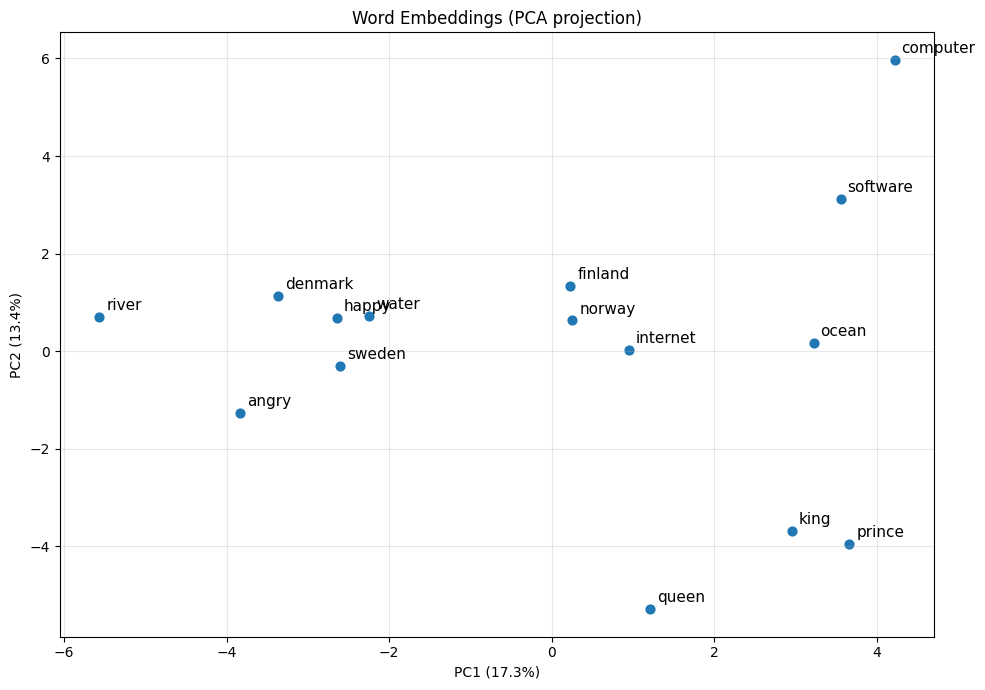

In [24]:
# Optional: PCA visualization of embeddings
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Pick some words to plot
words_to_plot = ['sweden', 'denmark', 'norway', 'finland',
                 'king', 'queen', 'prince',
                 'computer', 'software', 'internet',
                 'water', 'river', 'ocean',
                 'happy', 'sad', 'angry']

# Filter to words in vocabulary
valid = [(w, tokenizer.str_to_int[w]) for w in words_to_plot if w in tokenizer.str_to_int]
if len(valid) < 3:
    print('Not enough words in vocabulary for plot.')
else:
    labels, ids = zip(*valid)
    embs = model.embedding.weight.detach().cpu()[list(ids), :].numpy()

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embs)

    plt.figure(figsize=(10, 7))
    plt.scatter(coords[:, 0], coords[:, 1], s=40)
    for i, label in enumerate(labels):
        plt.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=11,
                     xytext=(5, 5), textcoords='offset points')
    plt.title('Word Embeddings (PCA projection)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
**Done!** All 5 parts complete.